In [1]:
import os
from tqdm import tqdm
import sys
from PIL import Image

sys.path.append(os.path.abspath("../src"))
import datasetCleaner as dc

In [2]:
DATA_PATH = "../data/train"
IMAGES_PATH = os.path.join(DATA_PATH, "images")
LABELS_PATH = os.path.join(DATA_PATH, "labels")
TARGETS_PATH = os.path.join(DATA_PATH, "targets")

In [3]:
LABEL_MAP = {
    "no-damage": "no_damage",
    "minor-damage": "minor_damage",
    "major-damage": "major_damage",
    "destroyed": "destroyed",
}

In [4]:
OUTPUT_PATH = "../data/processed"

splits = ["train", "val", "test"]
classes = list(LABEL_MAP.values())

for split in splits:
    for cls in classes:
        os.makedirs(os.path.join(OUTPUT_PATH, split, cls), exist_ok=True)

In [5]:
def process_split(scene_ids, split_name):
    counter = 0

    for scene_id in tqdm(scene_ids):

        img_path = os.path.join(IMAGES_PATH, scene_id + "_post_disaster.png")
        json_path = os.path.join(LABELS_PATH, scene_id + "_post_disaster.json")

        if not os.path.exists(img_path) or not os.path.exists(json_path):
            continue

        img = Image.open(img_path).convert("RGB")
        json_data = dc.load_json(json_path)

        buildings = dc.extract_buildings(json_data)

        for b in buildings:
            bbox = dc.wkt_to_bbox(b["wkt"])

            if bbox is None or not dc.is_valid_bbox(bbox):
                continue

            xmin, ymin, xmax, ymax = bbox

            crop = img.crop((xmin, ymin, xmax, ymax))

            label = LABEL_MAP[b["damage"]]

            save_dir = os.path.join(OUTPUT_PATH, split_name, label)

            filename = f"{scene_id}_{counter}.png"
            save_path = os.path.join(save_dir, filename)

            crop.save(save_path)

            counter += 1

In [6]:
train_ids = dc.load_ids("../data/train.txt")
val_ids   = dc.load_ids("../data/val.txt")
test_ids  = dc.load_ids("../data/test.txt")

print(len(train_ids), len(val_ids), len(test_ids))

1959 420 420


In [7]:
process_split(train_ids, "train")
process_split(val_ids, "val")
process_split(test_ids, "test")

100%|██████████| 420/420 [00:31<00:00, 13.34it/s]


In [8]:
from collections import Counter

def count_images(path):
    counts = {}

    for cls in os.listdir(path):
        cls_path = os.path.join(path, cls)
        counts[cls] = len(os.listdir(cls_path))

    return counts


print("Train:", count_images("../data/processed/train"))
print("Val:", count_images("../data/processed/val"))
print("Test:", count_images("../data/processed/test"))

Train: {'destroyed': 8966, 'major_damage': 13854, 'minor_damage': 13599, 'no_damage': 95262, 'un_classified': 628}
Val: {'destroyed': 1469, 'major_damage': 3493, 'minor_damage': 2332, 'no_damage': 18774, 'un_classified': 180}
Test: {'destroyed': 1465, 'major_damage': 2552, 'minor_damage': 2837, 'no_damage': 17899, 'un_classified': 179}


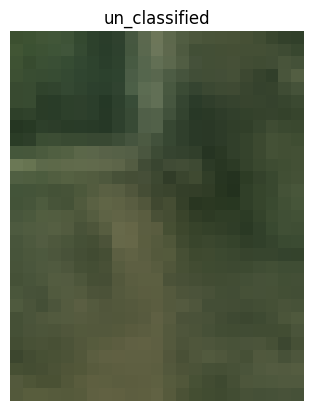

In [9]:
import random
import matplotlib.pyplot as plt

def show_random_sample(split="train"):
    cls = random.choice(os.listdir(f"../data/processed/{split}"))
    img_name = random.choice(os.listdir(f"../data/processed/{split}/{cls}"))

    img_path = os.path.join("../data/processed", split, cls, img_name)

    img = Image.open(img_path)

    plt.imshow(img)
    plt.title(cls)
    plt.axis("off")
    plt.show()

show_random_sample()